### Data Preparation ###

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# Merging our data from data_sensors and data_optimal_values
data_sensors = pd.read_csv("plant_health_data.csv")
data_optimal_values = pd.read_csv("optimal_values.csv")

data = pd.merge(
    data_sensors,
    data_optimal_values,
    left_on='Plant_ID',
    right_on='plant_id',
    how='left'
)

data = data.drop(columns=["Plant_ID", "plant_id", "Timestamp", "Soil_pH", "Soil_Temperature", "Nitrogen_Level", "Phosphorus_Level", "Potassium_Level", "Chlorophyll_Content", "Electrochemical_Signal", "Plant_Health_Status"])

data

,Soil_Moisture,Ambient_Temperature,Humidity,Light_Intensity,optimal_air_temperature,optimal_air_humidity,optimal_soil_humidity,optimal_light_intensity
0,27.521109,22.240245,55.291904,556.172805,26.3,62,82,911
1,14.835566,21.706763,63.949181,596.136721,26.3,62,82,911
2,17.086362,21.180946,67.837956,591.124627,26.3,62,82,911
3,15.336156,22.593302,58.190811,241.412476,26.3,62,82,911
4,39.822216,28.929001,63.772036,444.493830,26.3,62,82,911
...,...,...,...,...,...,...,...,...
1195,29.665780,27.605285,54.668196,650.536854,26.5,64,70,898
1196,15.490782,22.108112,61.243143,768.760787,26.5,64,70,898
1197,23.495723,21.680240,40.693671,293.643366,26.5,64,70,898
1198,30.971675,23.019488,41.387107,492.952014,26.5,64,70,898


In [3]:
data = data.astype({"Soil_Moisture": 'int', "Humidity": 'int', "Light_Intensity": 'int'})
data = data.round({"Ambient_Temperature": 1})

# Soil humidity deficit (optimal - current -> to get a positive value when it needs water)
data['soil_deficit'] = (data['optimal_soil_humidity'] - data['Soil_Moisture'])

# Ratio version (how dry is the plant relative to its ideal soil humidity)
data['soil_deficit_ratio'] = (data['soil_deficit'] / data['optimal_soil_humidity'])

# Temperature deviation (current - optimal -> get a postive value when it's hotter than ideal)
data['temp_deviation'] = (data['Ambient_Temperature'] - data['optimal_air_temperature'])

# Air humidity deficit (optimal - current -> positive means the air is too dry)
data['air_hum_deficit'] = (data['optimal_air_humidity'] - data['Humidity'])

# Light deviation (current - optimal -> get a postive value when it's more light than ideal)
data['light_deviation'] = (data['Light_Intensity'] - data['optimal_light_intensity'])

# Approximate evapotranspiration (water loss due to heat, light, and dry air)
data['et_approx'] = ((data['Ambient_Temperature'] * data['Light_Intensity']) / (data['Humidity'] + 1))

data = data.drop(columns=["optimal_light_intensity", "optimal_air_temperature", "optimal_air_humidity", "optimal_soil_humidity", "Soil_Moisture", "Ambient_Temperature", "Humidity", "Light_Intensity"])

data

,soil_deficit,soil_deficit_ratio,temp_deviation,air_hum_deficit,light_deviation,et_approx
0,55,0.670732,-4.1,7,-355,220.414286
1,68,0.829268,-4.6,-1,-315,202.081250
2,65,0.792683,-5.1,-5,-320,184.252941
3,67,0.817073,-3.7,4,-670,92.315254
4,43,0.524390,2.6,-1,-467,200.493750
...,...,...,...,...,...,...
1195,41,0.585714,1.1,10,-248,326.181818
1196,55,0.785714,-4.4,3,-130,273.754839
1197,47,0.671429,-4.8,24,-605,155.075610
1198,40,0.571429,-3.5,23,-406,269.428571


### Data Scaling ###

In [4]:
# Select features

data_scaled = data.copy()

features_to_scale = [
    'soil_deficit',
    'soil_deficit_ratio',
    'temp_deviation',
    'air_hum_deficit',
    'light_deviation',
    'et_approx'
]

scaler = StandardScaler()
data_scaled[features_to_scale] = scaler.fit_transform(data_scaled[features_to_scale])

data_scaled

,soil_deficit,soil_deficit_ratio,temp_deviation,air_hum_deficit,light_deviation,et_approx
0,0.420366,0.029956,-0.459929,-0.012996,-0.635218,-0.431508
1,1.536194,1.317849,-0.566968,-0.713880,-0.487013,-0.583940
2,1.278695,1.020642,-0.674007,-1.064321,-0.505538,-0.732175
3,1.450361,1.218780,-0.374298,-0.275827,-1.802329,-1.496600
4,-0.609628,-1.158869,0.974394,-0.713880,-1.050191,-0.597139
...,...,...,...,...,...,...
1195,-0.781294,-0.660695,0.653277,0.249836,-0.238770,0.447906
1196,0.420366,0.964032,-0.524152,-0.363438,0.198434,0.011997
1197,-0.266296,0.035617,-0.609784,1.476383,-1.561497,-0.974773
1198,-0.867126,-0.776747,-0.331482,1.388772,-0.824179,-0.023974


### Creating the model ###
- ML clustering discovers patterns of similar environmental conditions
- The model can discover unexpected patterns
- Good feature engineering reduces the need for advanced ML (like in our case the thresholds he have)
- To combine K-means with logic; ex, if plant stays in dry cluster for 2 hours -> water
- Maybe we can do PCA for dimensionality reduction so we can visualize clusters

### Applying PCA ###

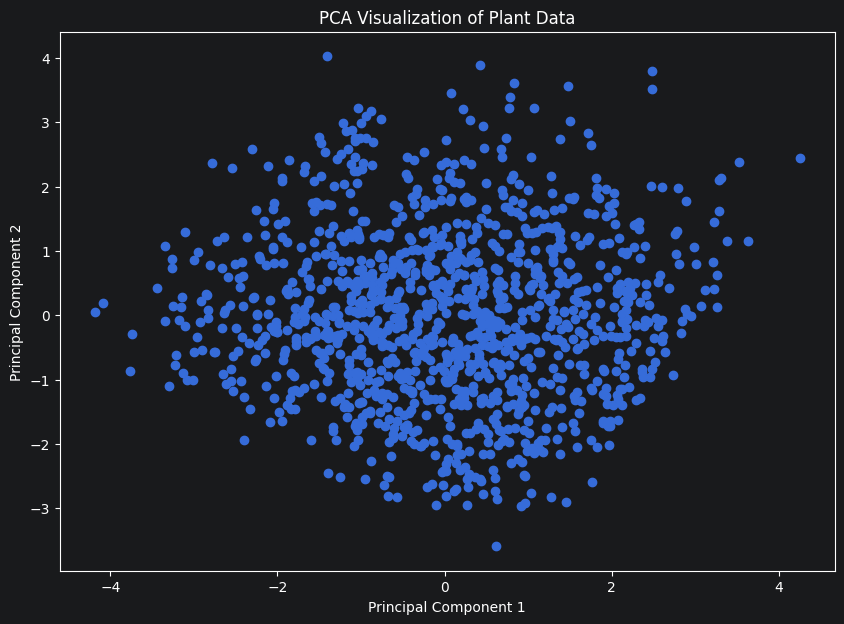

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_scaled[features_to_scale])

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],   # Principal Component 1
    X_pca[:, 1]    # Principal Component 2
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization of Plant Data")

plt.show()

### Applying K-means

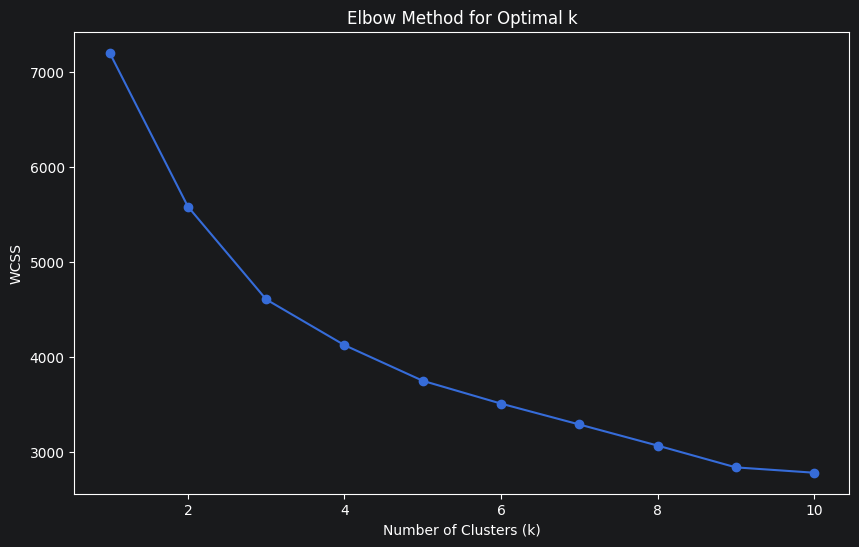

In [6]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(data_scaled[features_to_scale])

    # WCSS = Within-Cluster Sum of Squares
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")

plt.title("Elbow Method for Optimal k")

plt.show()

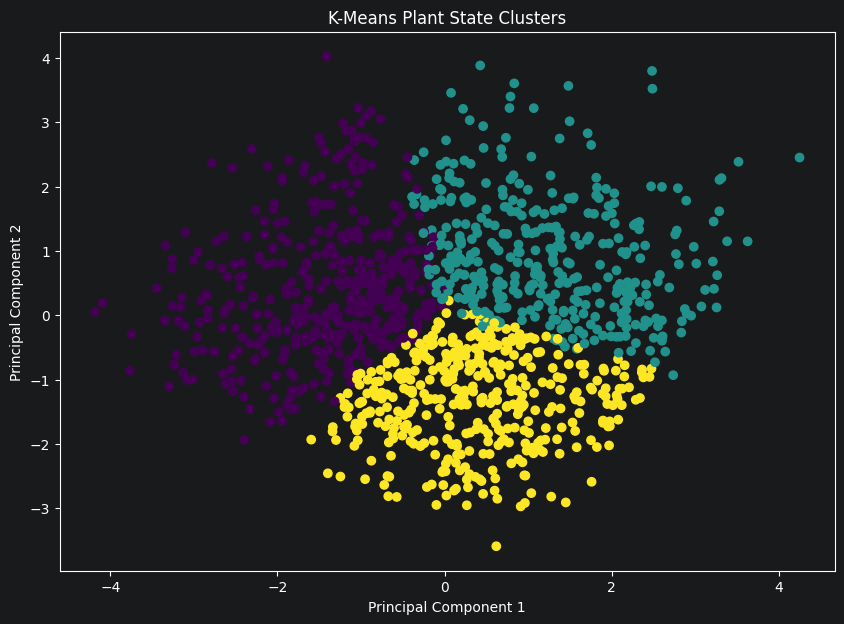

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(
    data_scaled[features_to_scale]
)

data_scaled['cluster'] = clusters

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],   # PCA component 1
    X_pca[:, 1],   # PCA component 2
    c=data_scaled['cluster']   # Color by cluster
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Plant State Clusters")

plt.show()

In [8]:
cluster_summary = data_scaled.groupby('cluster')[features_to_scale].mean()

cluster_summary

,soil_deficit,soil_deficit_ratio,temp_deviation,air_hum_deficit,light_deviation,et_approx
cluster,,,,,,
0,-1.005065,-1.007957,0.03638,-0.130909,-0.359566,-0.243405
1,0.387809,0.349467,0.24085,0.254251,0.999771,0.983926
2,0.705901,0.745308,-0.26699,-0.101046,-0.563061,-0.672093


| Feature              | Negative Value                                  | Around 0                   | Positive Value                                           |
| -------------------- | ----------------------------------------------- | -------------------------- | -------------------------------------------------------- |
| `soil_deficit`       | Soil is wetter / closer to optimal than average | Average dryness level      | Soil is drier than average                               |
| `soil_deficit_ratio` | Low relative dryness                            | Average relative dryness   | High relative dryness compared to optimal                |
| `temp_deviation`     | Cooler than optimal                             | Near optimal temperature   | Hotter than optimal                                      |
| `air_hum_deficit`    | Air is more humid than optimal                  | Near optimal humidity      | Air is drier than optimal                                |
| `light_deviation`    | Less light than optimal                         | Near optimal light         | More light than optimal                                  |
| `et_approx`          | Lower-than-average water loss conditions        | Average evapotranspiration | Higher-than-average evaporation/transpiration conditions |

### Cluster 0 - Healthy / Stable Conditions ###
| Feature                      | Interpretation                                                               |
| ---------------------------- | ---------------------------------------------------------------------------- |
| `soil_deficit = -1.00`       | Soil is significantly less dry than average → moisture is relatively healthy |
| `soil_deficit_ratio = -1.00` | Low relative dryness compared to plant needs                                 |
| `temp_deviation = 0.04`      | Temperature is very close to optimal                                         |
| `air_hum_deficit = -0.13`    | Air humidity is slightly better than optimal                                 |
| `light_deviation = -0.36`    | Light is somewhat below optimal                                              |
| `et_approx = -0.24`          | Lower-than-average evapotranspiration / water loss                           |

- The environment is calm and relatively balanced. Soil moisture is healthy, temperature is close to ideal, and the plant is not losing water rapidly. These conditions likely represent stable or recently watered periods with lower environmental stress.

### Cluster 1 - Active Drying Stress ###
| Feature                     | Interpretation                                  |
| --------------------------- | ----------------------------------------------- |
| `soil_deficit = 0.39`       | Soil is moderately drier than average           |
| `soil_deficit_ratio = 0.35` | Moderate relative water deficit                 |
| `temp_deviation = 0.24`     | Slightly hotter than optimal                    |
| `air_hum_deficit = 0.25`    | Air is drier than optimal                       |
| `light_deviation = 1.00`    | Significantly more light than optimal           |
| `et_approx = 0.98`          | Very high evapotranspiration / rapid water loss |

- The environment itself is aggressively drying the plant. Strong light exposure, warmer temperatures, and dry air are increasing evaporation and transpiration, causing the plant to lose water quickly.

### Cluster 2 — Critical Dryness / Accumulated Water Deficit ###

| Feature                     | Interpretation                        |
| --------------------------- | ------------------------------------- |
| `soil_deficit = 0.71`       | Soil is severely dry                  |
| `soil_deficit_ratio = 0.75` | Very high relative dryness            |
| `temp_deviation = -0.27`    | Slightly cooler than optimal          |
| `air_hum_deficit = -0.10`   | Air humidity is relatively acceptable |
| `light_deviation = -0.56`   | Light is below optimal                |
| `et_approx = -0.67`         | Low current evapotranspiration        |


- The current environment is not highly stressful, but the soil is already critically depleted of moisture. This likely represents accumulated dryness caused by insufficient watering over time rather than immediate environmental stress.


**If we want to water plant according to the clustering algorithm:** We should not water the plant imediatelly because the sensor can create noise.
*Instead:* If plant stays in drying cluster for 2–3 consecutive readings -> water


### Testing Clusters ###

In [9]:
import pandas as pd

# TEST READINGS

test_readings = [

    # SHOULD BE: healthy_stable
    {
        'name': 'Healthy Stable',

        'Soil_Moisture': 78,
        'Ambient_Temperature': 24,
        'Humidity': 68,
        'Light_Intensity': 600,

        'optimal_soil_humidity': 80,
        'optimal_air_temperature': 24,
        'optimal_air_humidity': 65,
        'optimal_light_intensity': 700
    },

    # SHOULD BE: active_drying_stress

    {
        'name': 'Active Drying Stress',

        'Soil_Moisture': 50,
        'Ambient_Temperature': 30,
        'Humidity': 40,
        'Light_Intensity': 950,

        'optimal_soil_humidity': 80,
        'optimal_air_temperature': 24,
        'optimal_air_humidity': 65,
        'optimal_light_intensity': 700
    },

    # SHOULD BE: critical_dryness

    {
        'name': 'Critical Dryness',

        'Soil_Moisture': 20,
        'Ambient_Temperature': 22,
        'Humidity': 60,
        'Light_Intensity': 400,

        'optimal_soil_humidity': 80,
        'optimal_air_temperature': 24,
        'optimal_air_humidity': 65,
        'optimal_light_intensity': 700
    }
]

# CLUSTER LABELS

cluster_labels = {
    0: 'healthy_stable',
    1: 'active_drying_stress',
    2: 'critical_dryness'
}

# LOOP THROUGH TEST READINGS

for reading in test_readings:

    print("\n========================================")
    print("Testing:", reading['name'])
    print("========================================")


    new_data = pd.DataFrame([reading])

    # Soil humidity deficit
    new_data['soil_deficit'] = (
        new_data['optimal_soil_humidity']
        - new_data['Soil_Moisture']
    )

    # Ratio version
    new_data['soil_deficit_ratio'] = (
        new_data['soil_deficit']
        / new_data['optimal_soil_humidity']
    )

    # Temperature deviation
    new_data['temp_deviation'] = (
        new_data['Ambient_Temperature']
        - new_data['optimal_air_temperature']
    )

    # Air humidity deficit
    new_data['air_hum_deficit'] = (
        new_data['optimal_air_humidity']
        - new_data['Humidity']
    )

    # Light deviation
    new_data['light_deviation'] = (
        new_data['Light_Intensity']
        - new_data['optimal_light_intensity']
    )

    # Approximate evapotranspiration
    new_data['et_approx'] = (
        (
            new_data['Ambient_Temperature']
            * new_data['Light_Intensity']
        )
        /
        (new_data['Humidity'] + 1)
    )

    # FEATURES USED BY MODEL

    features = [
        'soil_deficit',
        'soil_deficit_ratio',
        'temp_deviation',
        'air_hum_deficit',
        'light_deviation',
        'et_approx'
    ]

    # SCALE USING TRAINED SCALER

    new_scaled = pd.DataFrame(
        scaler.transform(new_data[features]),
        columns=features
    )

    # PREDICT CLUSTER

    predicted_cluster = kmeans.predict(new_scaled)[0]

    predicted_state = cluster_labels[
        predicted_cluster
    ]


    # PRINT RESULTS

    print("Predicted Cluster:", predicted_cluster)
    print("Predicted State:", predicted_state)



Testing: Healthy Stable
Predicted Cluster: 0
Predicted State: healthy_stable

Testing: Active Drying Stress
Predicted Cluster: 1
Predicted State: active_drying_stress

Testing: Critical Dryness
Predicted Cluster: 2
Predicted State: critical_dryness


### Generated data from Mario & Patrik ###

In [10]:
from datapreparation.data_preparation import Data_Preparation as dp

prep = dp(path="../../datapreparation/mockdata/")
X, y = prep.prepare_data_general_pump_time()
X

,hours_since_watering,soil_deficit,soil_deficit_ratio,temp_deviation,air_hum_deficit,light_deviation,deficit_x_temp,deficit_x_light,deficit_x_air,et_approx
0,0.0,-0.38,-0.006609,-0.51,-1.55,139.98,0.1938,-53.1924,0.5890,538.480735
1,0.0,0.67,0.037853,-0.81,-1.80,2435.50,-0.5427,1631.7850,-1.2060,9537.273686
2,0.0,-0.12,-0.001914,-1.27,-0.65,832.11,0.1524,-99.8532,0.0780,861.004877
3,0.0,-0.17,-0.002511,-0.73,1.82,413.82,0.1241,-70.3494,-0.3094,647.701245
4,0.0,0.17,0.003712,0.39,2.88,173.51,0.0663,29.4967,0.4896,353.698453
...,...,...,...,...,...,...,...,...,...,...
79444,339.0,12.87,0.711050,-2.08,3.07,-7124.18,-26.7696,-91688.1966,39.5109,77.096356
79445,363.0,12.24,0.267249,-2.81,-1.47,-489.50,-34.3944,-5991.4800,-17.9928,0.000000
79446,339.0,12.90,0.720670,-2.59,-1.70,-7500.20,-33.4110,-96752.5800,-21.9300,0.000000
79447,135.0,13.98,0.356633,-2.32,-4.18,-553.20,-32.4336,-7733.7360,-58.4364,0.000000
